У цьому домашньому завданні ми продовжуємо працювати з набором даних `Yulu`, з яким почали працювати в "hw 4.3. Робота з DataFrame. Діаграма розсіювання.". Фокус цього ДЗ в тому, аби будувати візуалізації використовуючи методи pandas.DataFrame. Це дозволяє будувати візуалізації ще швидше.

Документація до тої частини бібліотеки, з якою тут працюємо

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

### Профіль колонок набору даних:

- **datetime**: дата та час зібрані погодинно
- **season**: сезон (1: весна, 2: літо, 3: осінь, 4: зима)
- **holiday**: чи є день святковим (витягнуто з http://dchr.dc.gov/page/holiday-schedule)
- **workingday**: якщо день не є вихідним або святковим, то позначається як 1, в іншому випадку – 0.
- **weather**:
  1. Ясно, Мало хмарно, частково хмарно
  2. Туман + Хмарно, Туман + Розірвані хмари, Туман + Мало хмарно, Туман
  3. Легкий сніг, Легкий дощ + Гроза + Розсіяні хмари, Легкий дощ + Розсіяні хмари
  4. Сильний дощ + Крижані кулі + Гроза + Туман, Сніг + Туман
- **temp**: температура в градусах Цельсія
- **atemp**: як відчувається температура в градусах Цельсія
- **humidity**: вологість
- **windspeed**: швидкість вітру
- **casual**: кількість неформальних користувачів
- **registered**: кількість зареєстрованих користувачів
- **count**: загальна кількість велосипедів, взятих в оренду, включаючи неформальних та зареєстрованих користувачів

0. Імпортуйте бібліотеки `matplotlib.pyplot` та `pandas`.  Завантажте дані з файла yulu_rental.csv у pandas.DataFrame df.

In [7]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
drive.mount('/content/drive')
path='/content/drive/MyDrive/yulu_rental.csv'
df=pd.read_csv(path)


Mounted at /content/drive


In [8]:
df.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


1.1. Користуючись групою методів `pandas.plot` побудуйте гістограму кількості зареєстрованих користувачів з налаштуваннями за замовченням (тобто без жодних додаткових параметрів).

(array([4459., 2694., 1775.,  873.,  461.,  262.,  142.,  126.,   81.,
          13.]),
 array([  0. ,  88.6, 177.2, 265.8, 354.4, 443. , 531.6, 620.2, 708.8,
        797.4, 886. ]),
 <BarContainer object of 10 artists>)

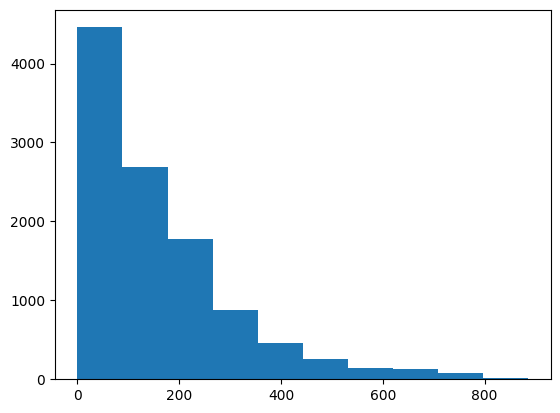

In [11]:
plt.hist(df['registered'], bins=10)


1.2. Побудуйте гістограму для цього ж показника, але задайте кількість бінів рівну 30 і задайте прозорість 0.5. Додайте підписи за осями ОХ і ОУ, а також назву дівграмі. Опишіть свої спостереження. Що бачите? Чому дані можуть мати такий розподіл?

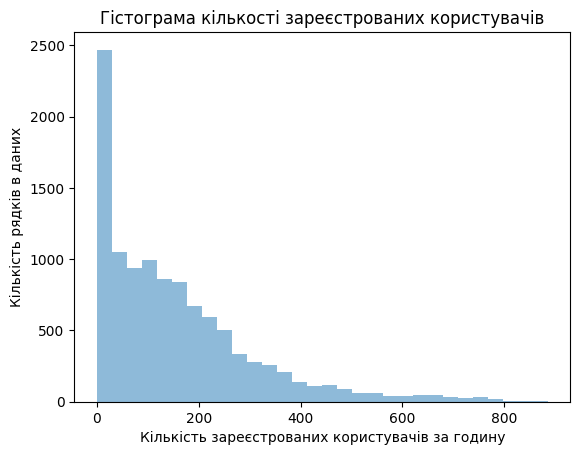

In [16]:
plt.hist(df['registered'],bins=30, alpha=0.5)


plt.title('Гістограма кількості зареєстрованих користувачів')
plt.xlabel('Кількість зареєстрованих користувачів за годину')
plt.ylabel('Кількість рядків в даних')


plt.show()

Гістограма має високий "пік" біля малих значень (зліва) і довгий "хвіст", що тягнеться вправо до великих значень. Це означає, що більшість часу кількість оренд велосипедів невелика, а дуже високі показники зустрічаються рідко.
Наявність викидів: "Хвіст" графіка показує окремі години, коли кількість реєстрацій була аномально високою (800+), але таких випадків дуже мало порівняно з загальною масою.
Такий розподіл каже нам про те, що попит на сервіс не є рівномірним. Він дуже чутливий до зовнішніх факторів (час доби, погода).

Має вийти щось таке (може бути без сітки):

![](https://drive.google.com/uc?export=view&id=1Pb3UD8cmg_V0LLf8A4feOepTDXMqEAf8)


--------

Перетворимо колонку `datetime` на тип даних `pd.datetime` - це нам доопоможе в подальшій роботі. Просто запустіть колонку нижче і занатуйте собі цей метод роботи з колонкою, в якій міститься дата і час.

In [10]:
df['datetime'] = pd.to_datetime(df.datetime)

І створимо нову колонку `dayofweek` для того, аби дослідити детальніше, коли у нас немає поїздок.

In [11]:
df['dayofweek'] = df.datetime.dt.day_of_week

Переглянемо значення в колонкці. Колонка dayofweek містить числа від 0 до 6 включно, де 0 відповідає понеділку.

In [12]:
df[['datetime','dayofweek']][df.dayofweek==0].head(10)

,datetime,dayofweek
47,2011-01-03 00:00:00,0
48,2011-01-03 01:00:00,0
49,2011-01-03 04:00:00,0
50,2011-01-03 05:00:00,0
51,2011-01-03 06:00:00,0
52,2011-01-03 07:00:00,0
53,2011-01-03 08:00:00,0
54,2011-01-03 09:00:00,0
55,2011-01-03 10:00:00,0
56,2011-01-03 11:00:00,0


2. Проведемо аналіз нульової активності зареєстрованих користувачів за днями тижня. Для цього
  1. Виберіть з набору даних усі записи, де кількість зареєстрованих користувачів дорівнює 0. Групуйте ці записи за днями тижня (`dayofweek`) та обчисліть кількість нульових записів для кожного дня.
  2. Після групування, використайте графік типу "bar" для візуалізації результатів. Кожна смужка на графіку має відображати кількість записів у даних для цього дня тижня, коли не було зареєстровано жодної поїздки користувачами.

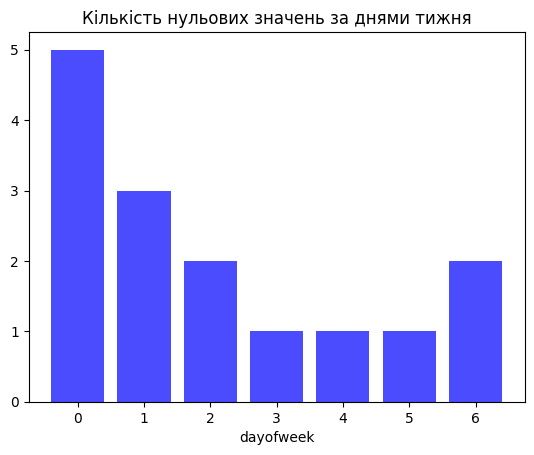

In [21]:
zero_data = df[df['registered'] == 0].groupby('dayofweek')['registered'].count()


plt.bar(zero_data.index, zero_data.values, color='blue', alpha=.7)
plt.title('Кількість нульових значень за днями тижня')
plt.xlabel('dayofweek')

plt.show()



Як бачимо, найменша кількість реєстрацій (набільша кількість нульових значень - 5) в нас спостерігається у понеділок, найбільша кількість реєстрацій- в кінці тижня перед вихідними. Це може бути пвязаним з сімейними прогулянками, прогулянками у вільний час (ближче до вікенду) і відпочинком, повязаним з активними видами - велосипедною прогулянкою. По понеділках користувачі мають більшу зайнятість і в основному користуються транспортом вже зареєстровані користувачі( мабуть, щоб витрачати також менше часу на реєстрацію саме в зайнятий день на початку рочоого тижня).

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1FXNzMa7rTdBQDwXSQfPTtPX5CHZK9A4X)

3. Проведемо аналіз загальної кількості зареєстрованих покристувачів за різними погодними умовами.
Згрупуйте всі дані за погодними умовами і визначте суму кількості зареєстрованих користувачів для кожної погодньої умови.
Побудуйте стовпачасту діаграму, які відобразить результат обчислень.
Зверніться до опису даних та дайте відповідь: чи побудована візуалізація має логічний сенс з точки зору опису даних.

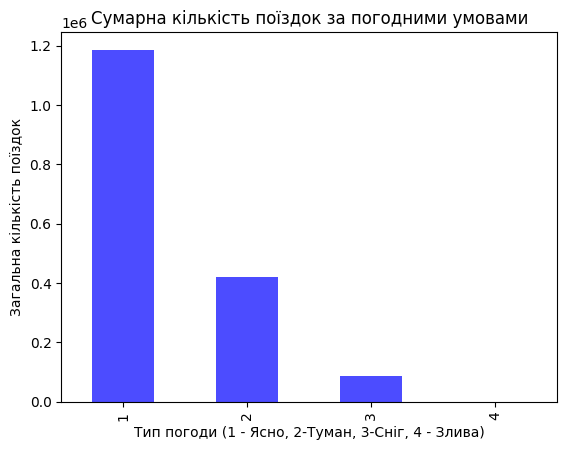

In [34]:
weather_activity = df.groupby('weather')['registered'].sum()


weather_activity.plot.bar(color='blue', alpha=.7)
plt.title('Сумарна кількість поїздок за погодними умовами')
plt.xlabel('Тип погоди (1 - Ясно, 2-Туман, 3-Сніг, 4 - Злива)')
plt.ylabel('Загальна кількість поїздок')
plt.show()

Висновок: очікувано найбільша кількість поіздок здійснюється в ясну погоду, набагато менше - в туман, навіть є поїздки у сніжну погоду, у зливу поїздки відсутні.
Комфорт — головний фактор: велосипед — це вид транспорту під відкритим небом. Більшість користувачів (особливо зареєстровані, які часто їдуть на роботу) не хочуть приїхати в офіс мокрими чи брудними. Тому при появі опадів (погода 3) вони масово припиняють користуватися велосипедами.

Безпека: Їзда під час зливи чи сильного снігу (погода 4) є небезпечною через слизьку дорогу та погану видимість, що додатково знижує попит на наші послуги

Психологічний аспект: Сонячна погода стимулює бажання користуватися велосипедом.

4. Користуючись групою методів pandas.plot побудуйте діаграму розсіювання (scatter plot) між вологістю і кількістю зареєстрованих користувачів. Встановіть прозорість на 0.5, а також налаштуйте діаграму так, аби колір кожної точки відповідав значенню температури за відчуттями (`atemp`).

Проаналізуйте графік, що спостерігаєте?

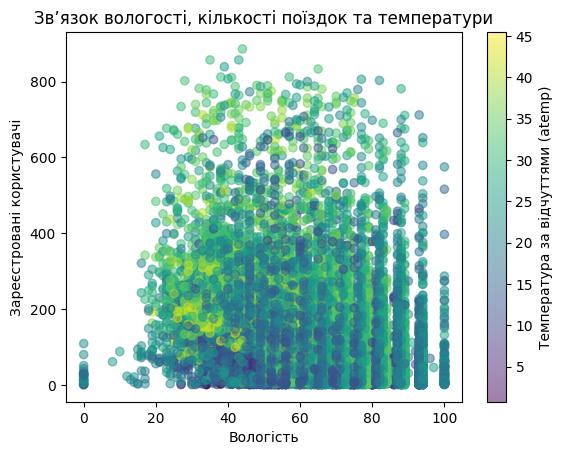

In [36]:
plt.scatter(df['humidity'], df['registered'], c=df['atemp'], cmap='viridis', alpha=0.5)


plt.colorbar(label='Температура за відчуттями (atemp)')


plt.title('Зв’язок вологості, кількості поїздок та температури')
plt.xlabel('Вологість')
plt.ylabel('Зареєстровані користувачі')

plt.show()

Спостереження : Більшість високих значень (багато поїздок) зосереджені в діапазоні вологості від 20 до 60%. Якщо вологість стає дуже високою (ближче до 100%), спостерігаємо, що кількість поїздок різко падає — мабуть це повязано з низьким рівнем комфорту під час ізди.Температура за відчуттями (Колір):можемо помітити, що «жовті» та «світло-зелені» точки знаходяться вище за інші. Це означає, що при відчуттях більшої температури на вулиці кількість зареєстрованих користувачів зростає - люди з більщим заохоченням користуються нашим транспортом.
Загальний висновок можемо зробити наступний: найбільша кількість поїздок відбувається у зоні з середніми рівнями вологості та відчуттям більших температур  — коли на вулиці спекотно по субєктивних відчуттях. При відчуттях низьких температур і низьких вологостях (темні точки), а також при  занадто високій вологості (правий край графіка), активність користувачів мінімальна.

Очікуваний результат:

![](https://drive.google.com/uc?export=view&id=1trepX8z23YwyP9P8cAko9IzwOZkvLo8y)